In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('car_dataset.csv',encoding='latin-1')

In [5]:
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2025,Acura,Integra A-SPEC,Full-size,1.5,4,AV7,Z,8.1,6.5,7.4,38,172,6,6
1,2025,Acura,Integra A-SPEC,Full-size,1.5,4,M6,Z,8.9,6.5,7.8,36,181,6,5
2,2025,Acura,Integra Type S,Full-size,2.0,4,M6,Z,11.1,8.3,9.9,29,230,5,5
3,2025,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,4
4,2025,Acura,MDX SH-AWD Type S,Sport utility vehicle: Standard,3.0,6,AS10,Z,13.8,11.2,12.4,23,291,4,4


In [6]:
df.shape

(651, 15)

In [8]:
df.drop(columns='Model year',inplace=True)

In [9]:
df.head()

,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,Acura,Integra A-SPEC,Full-size,1.5,4,AV7,Z,8.1,6.5,7.4,38,172,6,6
1,Acura,Integra A-SPEC,Full-size,1.5,4,M6,Z,8.9,6.5,7.8,36,181,6,5
2,Acura,Integra Type S,Full-size,2.0,4,M6,Z,11.1,8.3,9.9,29,230,5,5
3,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS10,Z,12.6,9.4,11.2,25,263,4,4
4,Acura,MDX SH-AWD Type S,Sport utility vehicle: Standard,3.0,6,AS10,Z,13.8,11.2,12.4,23,291,4,4


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  651 non-null    object 
 1   Model                 651 non-null    object 
 2   Vehicle class         651 non-null    object 
 3   Engine size (L)       651 non-null    float64
 4   Cylinders             651 non-null    int64  
 5   Transmission          651 non-null    object 
 6   Fuel type             651 non-null    object 
 7   City (L/100 km)       651 non-null    float64
 8   Highway (L/100 km)    651 non-null    float64
 9   Combined (L/100 km)   651 non-null    float64
 10  Combined (mpg)        651 non-null    int64  
 11  CO2 emissions (g/km)  651 non-null    int64  
 12  CO2 rating            651 non-null    int64  
 13  Smog rating           651 non-null    int64  
dtypes: float64(4), int64(5), object(5)
memory usage: 71.3+ KB


In [11]:
df.isna().sum()

Make                    0
Model                   0
Vehicle class           0
Engine size (L)         0
Cylinders               0
Transmission            0
Fuel type               0
City (L/100 km)         0
Highway (L/100 km)      0
Combined (L/100 km)     0
Combined (mpg)          0
CO2 emissions (g/km)    0
CO2 rating              0
Smog rating             0
dtype: int64

In [18]:
num_col=[]
for i in df.select_dtypes(include=np.number).columns:
    num_col.append(i)

print(num_col)

['Engine size (L)', 'Cylinders', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


In [20]:
cat_col=[]
for i in df.select_dtypes(exclude=np.number).columns:
    cat_col.append(i)

print(cat_col)

['Make', 'Model', 'Vehicle class', 'Transmission', 'Fuel type']


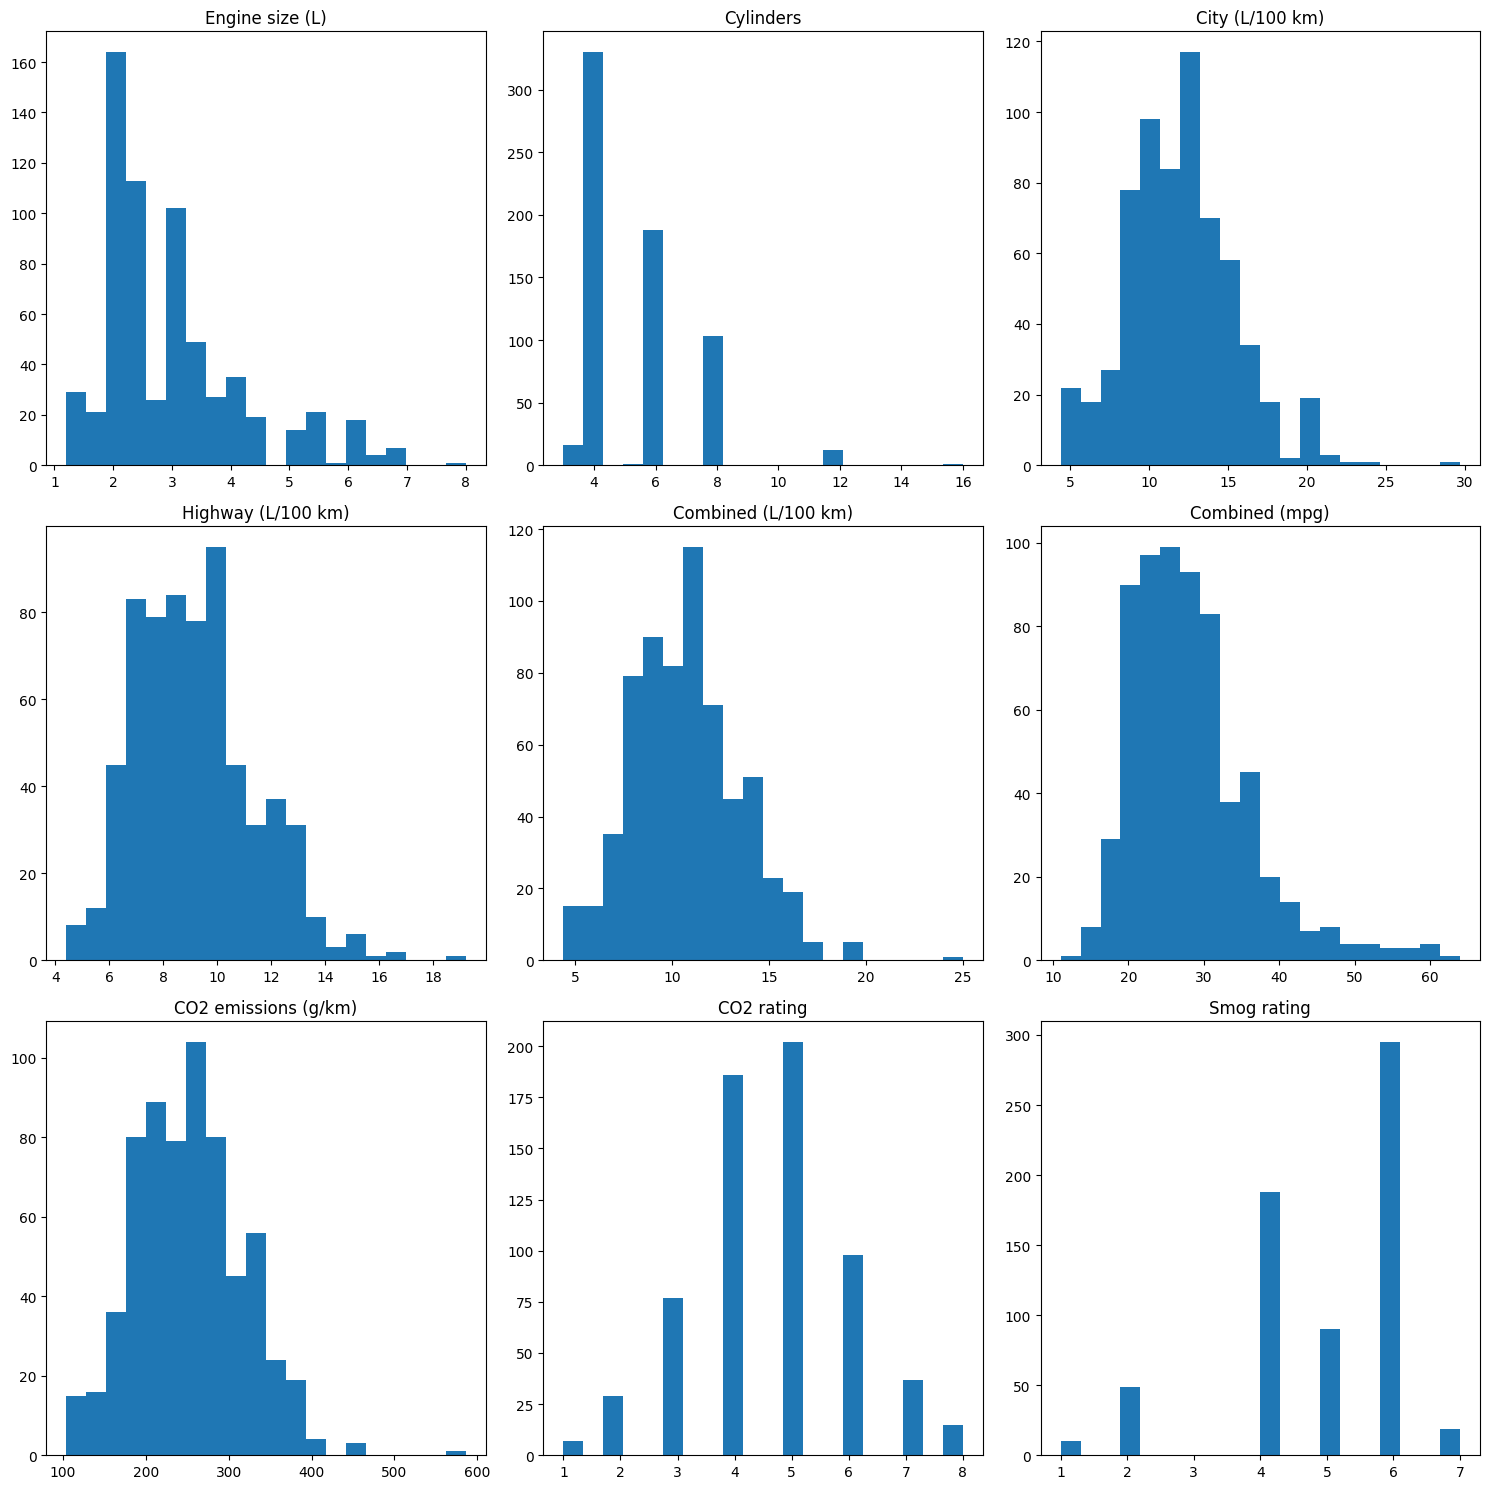

In [27]:
n = len(num_col)

rows = (n // 3) + (n % 3 > 0) 
cols = 3

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_col, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Total CO2 emissions by each car makers in year 2025')

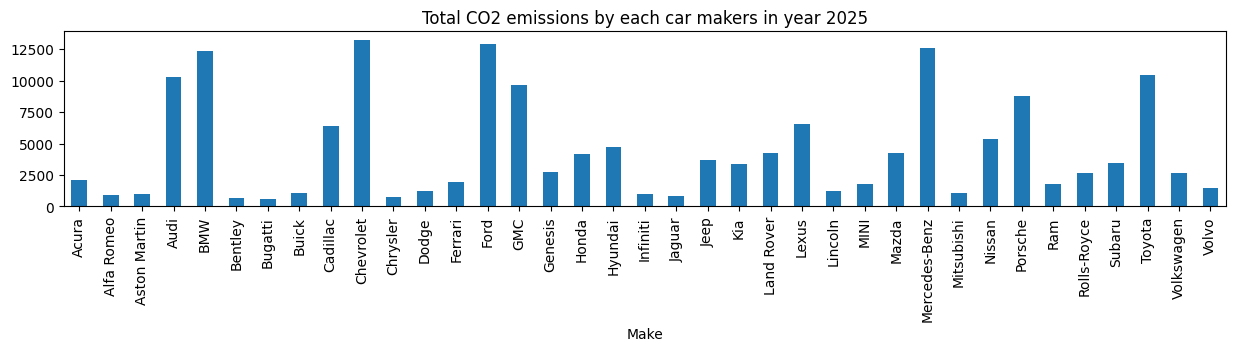

In [51]:
plt.figure(figsize=(15,5))
plt.subplot(2,1,1)
df.groupby('Make')['CO2 emissions (g/km)'].sum().plot(kind='bar')
plt.title('Total CO2 emissions by each car makers in year 2025')

Text(0.5, 1.0, 'Totle car brands')

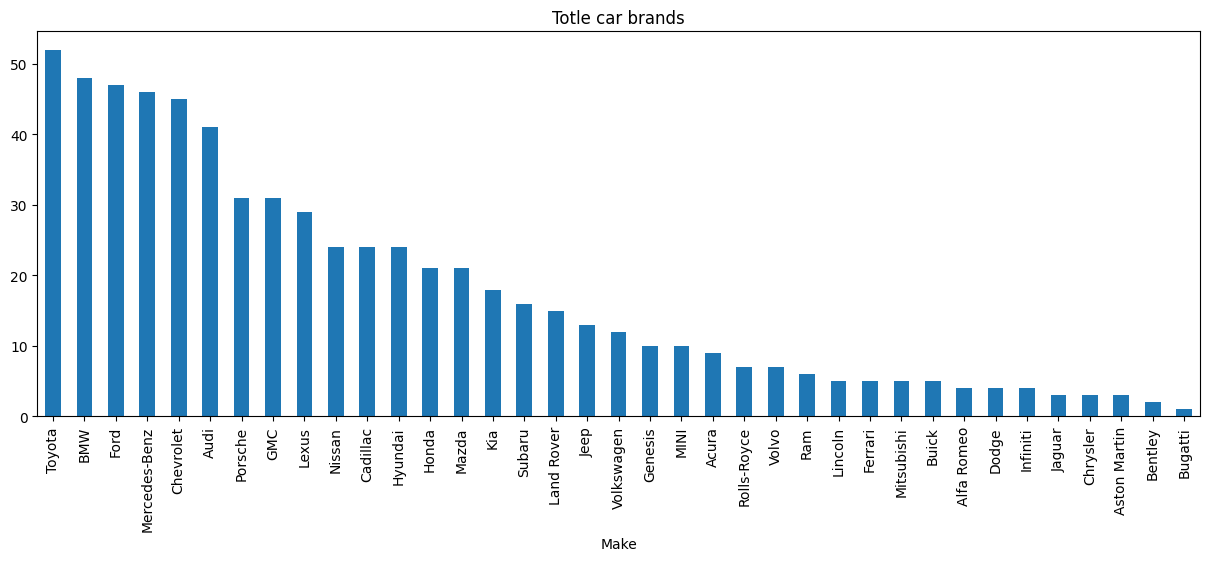

In [44]:
plt.figure(figsize=(15,5))
df['Make'].value_counts().plot(kind='bar')
plt.title('Totle car brands')

Text(0.5, 1.0, 'CO2 emissions/car_makers in year 2025')

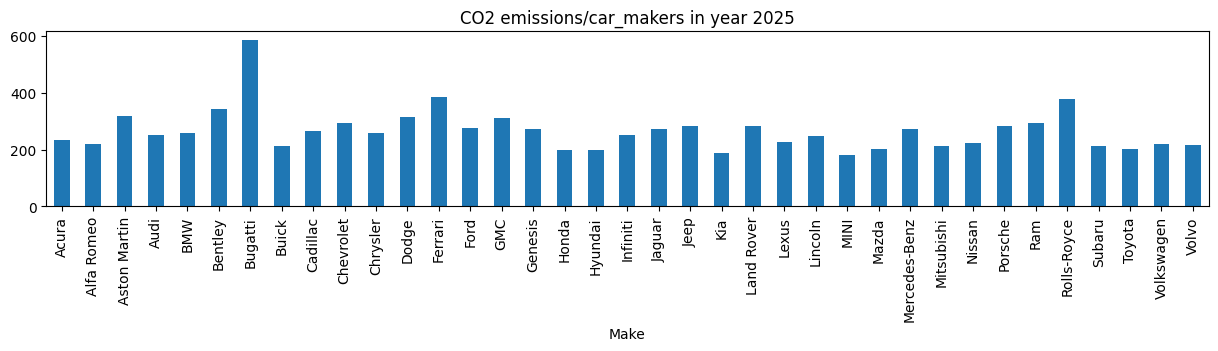

In [50]:
plt.figure(figsize=(15,5))
plt.subplot(2,1,1)
df.groupby('Make')['CO2 emissions (g/km)'].mean().plot(kind='bar')
plt.title('CO2 emissions/car_makers in year 2025')

Text(0.5, 1.0, 'Average CO2 emissions by fule in year 2025')

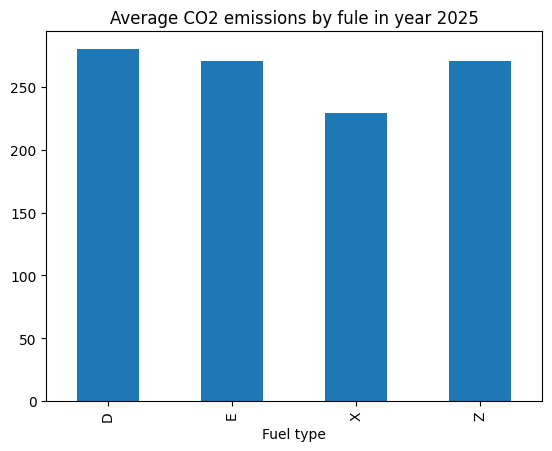

In [56]:
df.groupby('Fuel type')['CO2 emissions (g/km)'].mean().plot(kind='bar')
plt.title('Average CO2 emissions by fule in year 2025')

Text(0.5, 1.0, 'CO2 emissions by transmission')

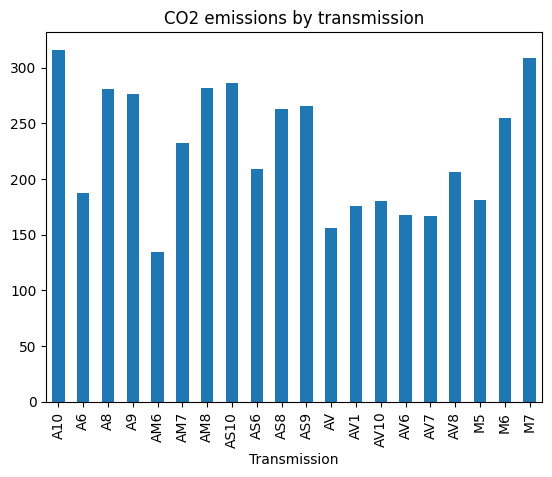

In [57]:
df.groupby('Transmission')['CO2 emissions (g/km)'].mean().plot(kind='bar')
plt.title('CO2 emissions by transmission')

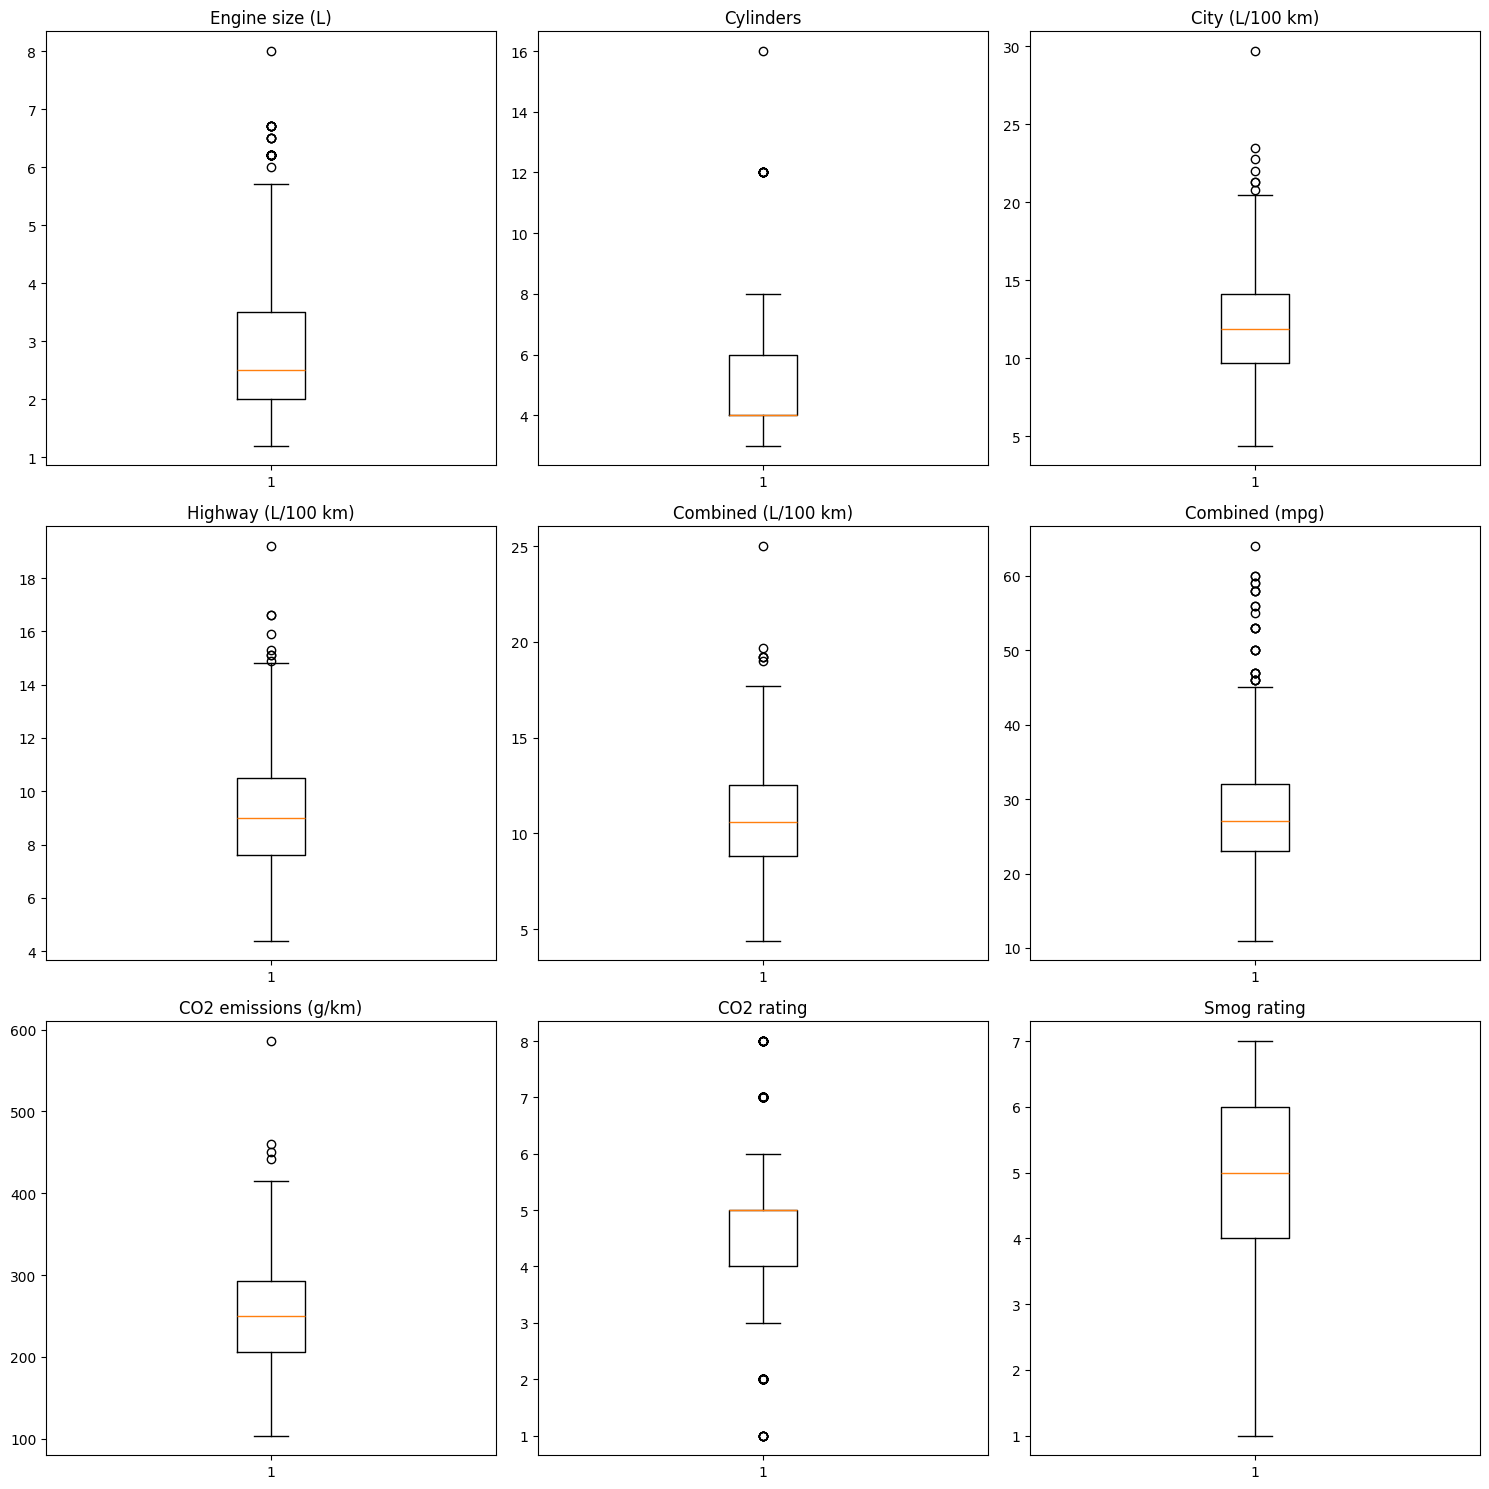

In [59]:
n = len(num_col)

rows = (n // 3) + (n % 3 > 0) 
cols = 3

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_col, 1):
    plt.subplot(rows, cols, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Corrilation matrix')

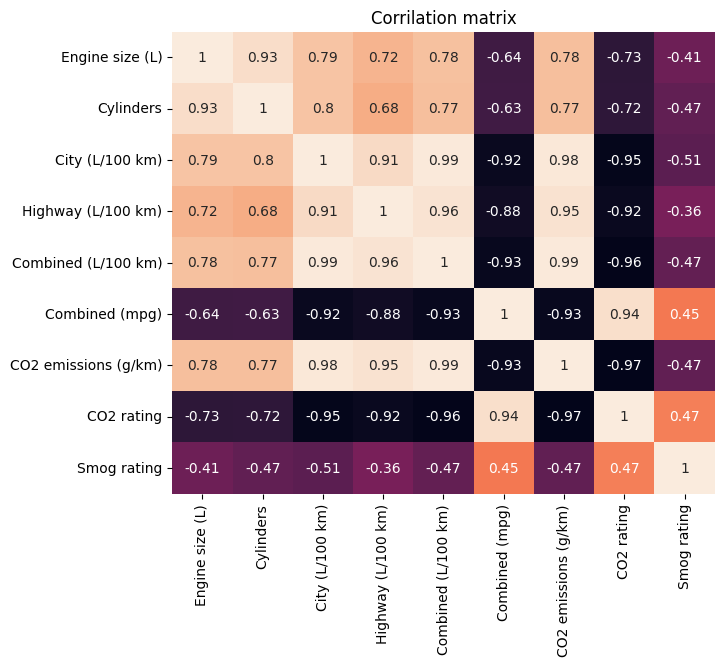

In [94]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(7,6))
sns.heatmap(corr,cbar=False,annot=True)
plt.title('Corrilation matrix')

In [107]:
y=df['CO2 emissions (g/km)']
X=df[num_col].drop(columns='CO2 emissions (g/km)')

In [108]:
X.head()

,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 rating,Smog rating
0,1.5,4,8.1,6.5,7.4,38,6,6
1,1.5,4,8.9,6.5,7.8,36,6,5
2,2.0,4,11.1,8.3,9.9,29,5,5
3,3.5,6,12.6,9.4,11.2,25,4,4
4,3.0,6,13.8,11.2,12.4,23,4,4


In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

               feature        VIF
0      Engine size (L)  54.864974
1            Cylinders  75.620515
2  Combined (L/100 km)  33.102439
3           CO2 rating  14.858937
4          Smog rating  19.669046


In [110]:
X.drop(columns=['City (L/100 km)','Highway (L/100 km)','Combined (mpg)'],inplace=True)

In [104]:
corr['CO2 emissions (g/km)']

Engine size (L)         0.777049
Cylinders               0.771301
City (L/100 km)         0.978018
Highway (L/100 km)      0.951696
Combined (L/100 km)     0.989245
Combined (mpg)         -0.926185
CO2 emissions (g/km)    1.000000
CO2 rating             -0.967019
Smog rating            -0.470179
Name: CO2 emissions (g/km), dtype: float64

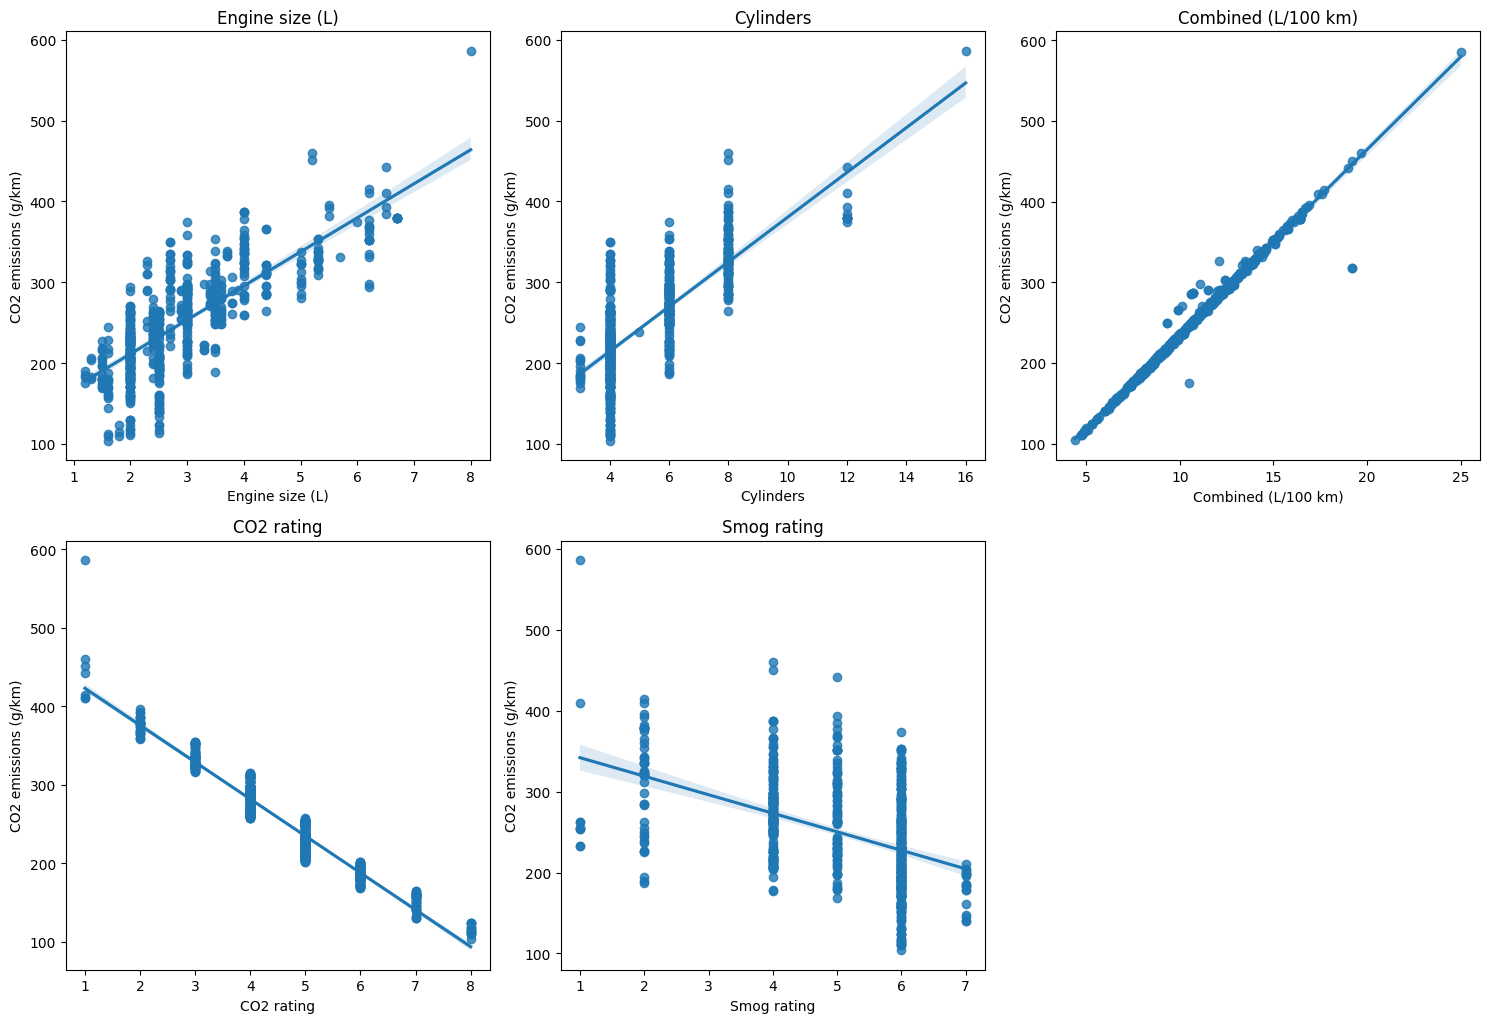

In [216]:
n = len(num_col)

rows = (n // 3) + (n % 3 > 0) 
cols = 3

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(X.columns, 1):
    plt.subplot(rows, cols, i)
    sns.regplot(x=df[col],y=y)
    plt.title(col)

plt.tight_layout()
plt.show()

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler

In [117]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [119]:
X_train.shape,X_test.shape

((520, 5), (131, 5))

In [120]:
y_train.shape,y_test.shape

((520,), (131,))

In [122]:
scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [123]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [145]:
y_pred1=model.predict(X_test_scaled)

In [146]:
residuals=y_test-y_pred1

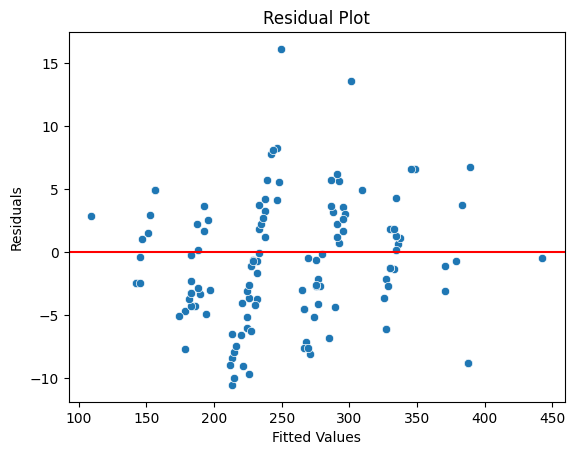

In [147]:
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_16128\2665350104.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals)


<Axes: xlabel='CO2 emissions (g/km)', ylabel='Density'>

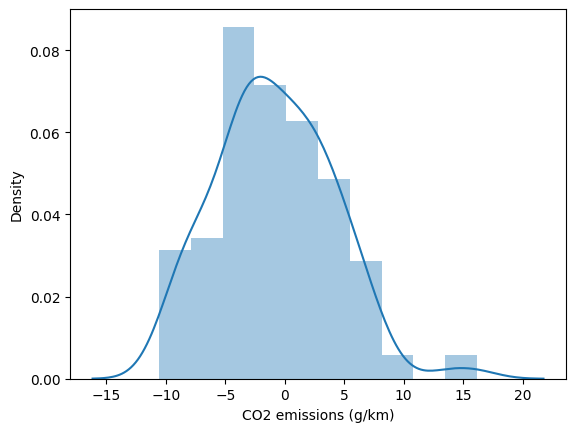

In [148]:
sns.distplot(residuals)

In [174]:
from sklearn.linear_model import RidgeCV
import numpy as np

alphas = np.logspace(-3, 3, 1000)  # values from 0.001 to 1000

model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_train_scaled, y_train)

print("Best alpha:", model.alpha_)

Best alpha: 2.412961183253607


In [190]:
from sklearn.linear_model import Ridge
Ridge = Ridge(alpha=100)

In [191]:
Ridge.fit(X_train_scaled, y_train)

,alpha,100
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [192]:
y_pred2 = Ridge.predict(X_test_scaled)

In [193]:
residual=y_test-y_pred2

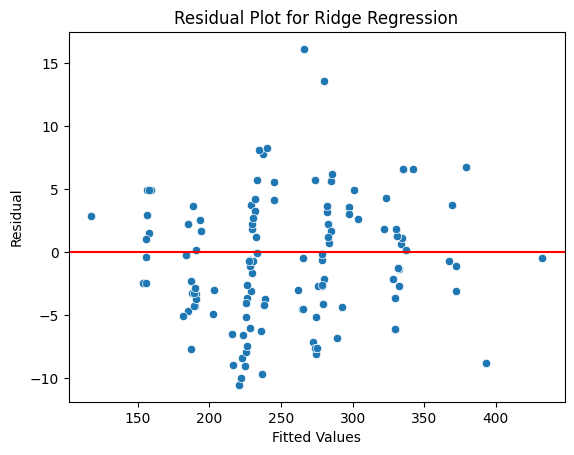

In [203]:
sns.scatterplot(x=y_pred2, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual Plot for Ridge Regression")
plt.show()

In [195]:
from sklearn.metrics import r2_score

In [196]:
model.score(X_test_scaled, y_test)

0.9944261690446524

In [197]:
Ridge.score(X_test_scaled, y_test)

0.9764096631088813

In [198]:
from sklearn.linear_model import Ridge
for a in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    print(a, model.score(X_test_scaled, y_test))

0.01 0.9955967953645254
0.1 0.995553961802932
1 0.9951189903510123
10 0.9910289601715854
100 0.9764096631088813


In [199]:
from sklearn.linear_model import LassoCV

model = LassoCV(alphas=None, cv=5)
model.fit(X_train_scaled, y_train)

print("Best alpha:", model.alpha_)

Best alpha: 0.38376165539029966


C:\Users\ankit\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


In [205]:
from sklearn.linear_model import Lasso

Lasso = Lasso(alpha=0.38376165539029966)
Lasso.fit(X_train_scaled, y_train)

y_pred3 = model.predict(X_test_scaled)

In [206]:
res=y_test-y_pred3

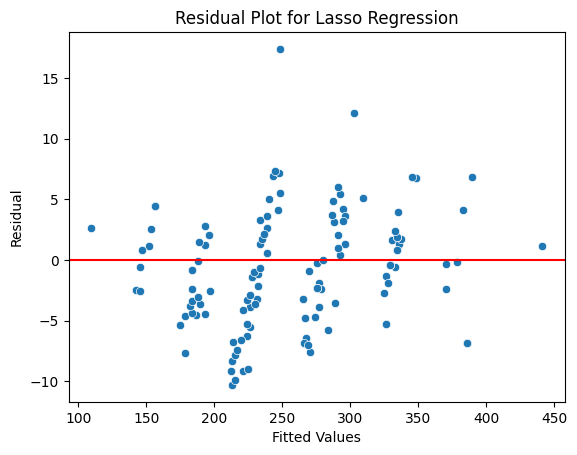

In [207]:
sns.scatterplot(x=y_pred3, y=res)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual Plot for Lasso Regression")
plt.show()

In [215]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Ridge Regression
ridge = Ridge(alpha=0.01)   # use your best alpha
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso Regression
lasso = Lasso(alpha=0.38376165539029966)   # you can tune this later
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Print R2 scores
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Ridge Regression R2:", r2_score(y_test, y_pred_ridge))
print("Lasso Regression R2:", r2_score(y_test, y_pred_lasso))

Linear Regression R2: 0.9956015448879894
Ridge Regression R2: 0.9955967953645254
Lasso Regression R2: 0.9949155434439109
